In [5]:
# =====================================
# 1) Librerías
# =====================================
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =====================================
# 2) Cargar modelo (.h5)
# =====================================
model = tf.keras.models.load_model("best_model.h5", compile=False)

# =====================================
# 3) Detectar última capa convolucional
# =====================================
def find_last_conv_layer(m):
    for layer in reversed(m.layers):
        if len(layer.output_shape) == 4:  # salida (H,W,C)
            return layer.name
    raise ValueError("No hay capas conv 4D")
    
last_conv = find_last_conv_layer(model)
print("Última conv:", last_conv)

# =====================================
# 4) Cargar y preprocesar RX de ejemplo
# =====================================
img_path = "neumonia_ejemplo.png"   # <- CAMBIA a tu imagen
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb = cv2.resize(img_rgb, (224,224))  # ajusta si tu modelo usa otro tamaño
img_rgb = img_rgb.astype(np.float32) / 255.0

# =====================================
# 5) Función Grad-CAM
# =====================================
def grad_cam_keras(model, img_rgb224, last_conv_layer_name, class_index=None):
    x = np.expand_dims(img_rgb224, 0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        if preds.shape[-1] == 1:   # binario con sigmoide
            prob = tf.nn.sigmoid(preds)[0,0]
            target = preds[:,0]
        else:                      # multiclase
            if class_index is None:
                class_index = tf.argmax(preds[0])
            target = preds[:, class_index]

    grads = tape.gradient(target, conv_out)          # (1,H,W,C)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0].numpy()
    weights = pooled_grads.numpy()
    cam = np.dot(conv_out, weights)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_rgb224.shape[1], img_rgb224.shape[0]))

    heatmap = (cam*255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = (0.4*heatmap_color + 0.6*(img_rgb224*255)).astype(np.uint8)

    return overlay, float(prob.numpy()) if preds.shape[-1]==1 else None

# =====================================
# 6) Ejecutar Grad-CAM
# =====================================
overlay, prob = grad_cam_keras(model, img_rgb, last_conv, class_index=0)

print("Probabilidad clase positiva:", prob)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Radiografía original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update th

ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)

In [6]:
import tensorflow as tf

# Intenta cargar forzando el modo "legacy"
model = tf.keras.models.load_model("best_model.h5", compile=False, safe_mode=False)
print("OK:", model.input_shape)


ValueError: Shape mismatch in layer #1 (named stem_conv)for weight stem_conv/kernel. Weight expects shape (3, 3, 1, 32). Received saved weight with shape (3, 3, 3, 32)

In [7]:
# =========================
# 1) Crear arquitectura base
# =========================
import tensorflow as tf
from tensorflow.keras import layers, Model

INPUT_SHAPE = (224, 224, 3)   # ajusta si entrenaste con otro tamaño
base = tf.keras.applications.DenseNet121(include_top=False,
                                         weights=None,  # no preentrenes aquí
                                         input_shape=INPUT_SHAPE)

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)   # binario
model = Model(base.input, out)

# =========================
# 2) Cargar pesos del .h5
# =========================
# Carga los pesos por nombre e ignora desajustes (por ejemplo, si la cabeza difiere)
model.load_weights("best_model.h5", by_name=True, skip_mismatch=True)

print("Modelo armado:", model.input_shape)
# Verifica el primer conv
first_conv = [l for l in model.layers if isinstance(l, layers.Conv2D)][0]
print("Primer conv kernel shape:", first_conv.get_weights()[0].shape)


Modelo armado: (None, 224, 224, 3)
Primer conv kernel shape: (7, 7, 3, 64)


In [8]:
import cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

def find_last_conv_layer(m):
    for layer in reversed(m.layers):
        if hasattr(layer, "output_shape") and len(layer.output_shape) == 4:
            return layer.name
    raise ValueError("No hay capas conv 4D")

last_conv = find_last_conv_layer(model)
print("Última conv:", last_conv)

# Carga imagen de prueba en RGB
img_path = "neumonia_ejemplo.png"
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_rgb  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb  = cv2.resize(img_rgb, (224,224)).astype(np.float32)/255.0

def grad_cam_keras(model, img_rgb224, last_conv_layer_name, class_index=0):
    x = np.expand_dims(img_rgb224, 0)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        if preds.shape[-1] == 1:
            target = preds[:,0]           # binario
            prob = tf.nn.sigmoid(preds)[0,0]
        else:
            target = preds[:, class_index]
            prob = tf.nn.softmax(preds)[0, class_index]
    grads = tape.gradient(target, conv_out)
    weights = tf.reduce_mean(grads, axis=(0,1,2)).numpy()
    cam = np.dot(conv_out[0].numpy(), weights)
    cam = np.maximum(cam,0); cam = cam/(cam.max()+1e-8)
    heat = (cam*255).astype(np.uint8)
    heat = cv2.applyColorMap(cv2.resize(heat,(224,224)), cv2.COLORMAP_JET)
    overlay = (0.4*heat + 0.6*(img_rgb224*255)).astype(np.uint8)
    return overlay, float(prob.numpy())

overlay, prob = grad_cam_keras(model, img_rgb, last_conv)
print("Probabilidad clase positiva:", prob)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,2,2); plt.title("Grad-CAM"); plt.imshow(overlay); plt.axis("off")
plt.show()


ValueError: No hay capas conv 4D

In [9]:
# 0) Asegura que el modelo esté "built" (materializa shapes)
_ = model(tf.zeros((1, 224, 224, 3), dtype=tf.float32))


In [10]:
# 1) Finder robusto de la última capa con salida 4D
def find_last_4d_layer(m):
    for layer in reversed(m.layers):
        try:
            out = layer.output  # KerasTensor
            if len(out.shape) == 4:
                return layer.name
        except Exception:
            continue
    # Fallback: la última Conv2D
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No hay capas con salida 4D ni Conv2D en el modelo.")

def list_4d_layers(m):
    print("Capas 4D detectadas (nombre, shape):")
    for layer in m.layers:
        try:
            out = layer.output
            if len(out.shape) == 4:
                print(f"  {layer.name:40s} {out.shape}")
        except:
            pass

list_4d_layers(model)
last_conv = find_last_4d_layer(model)
print("Última 4D seleccionada:", last_conv)


Capas 4D detectadas (nombre, shape):
  input_layer                              (None, 224, 224, 3)
  zero_padding2d                           (None, 230, 230, 3)
  conv1_conv                               (None, 112, 112, 64)
  conv1_bn                                 (None, 112, 112, 64)
  conv1_relu                               (None, 112, 112, 64)
  zero_padding2d_1                         (None, 114, 114, 64)
  pool1                                    (None, 56, 56, 64)
  conv2_block1_0_bn                        (None, 56, 56, 64)
  conv2_block1_0_relu                      (None, 56, 56, 64)
  conv2_block1_1_conv                      (None, 56, 56, 128)
  conv2_block1_1_bn                        (None, 56, 56, 128)
  conv2_block1_1_relu                      (None, 56, 56, 128)
  conv2_block1_2_conv                      (None, 56, 56, 32)
  conv2_block1_concat                      (None, 56, 56, 96)
  conv2_block2_0_bn                        (None, 56, 56, 96)
  conv2_block2_0_rel

In [11]:
# 2) Grad-CAM igual que antes (usa last_conv obtenido)
def grad_cam_keras(model, img_rgb224, last_conv_layer_name, class_index=0):
    x = np.expand_dims(img_rgb224, 0)
    grad_model = tf.keras.models.Model([model.inputs],
                                       [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        if preds.shape[-1] == 1:
            target = preds[:, 0]                 # binario
            prob = tf.nn.sigmoid(preds)[0, 0]
        else:
            target = preds[:, class_index]
            prob = tf.nn.softmax(preds)[0, class_index]
    grads = tape.gradient(target, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()
    cam = np.dot(conv_out[0].numpy(), weights)
    cam = np.maximum(cam, 0); cam = cam / (cam.max() + 1e-8)
    heat = (cam * 255).astype(np.uint8)
    heat = cv2.applyColorMap(cv2.resize(heat, (img_rgb224.shape[1], img_rgb224.shape[0])), cv2.COLORMAP_JET)
    overlay = (0.4 * heat + 0.6 * (img_rgb224 * 255)).astype(np.uint8)
    return overlay, float(prob.numpy())


In [14]:
# --- Cargar y preprocesar la radiografía (define img_rgb) ---
import cv2, numpy as np

img_path = "neumonia_ejemplo.jpg"  # <-- pon aquí tu imagen
img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {img_path}")

# Gris -> RGB (3 canales) y resize al tamaño de tu modelo (224 si así lo armaste)
img_rgb  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb  = cv2.resize(img_rgb, (224, 224)).astype(np.float32) / 255.0


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1018']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Probabilidad clase positiva: 0.6191874742507935


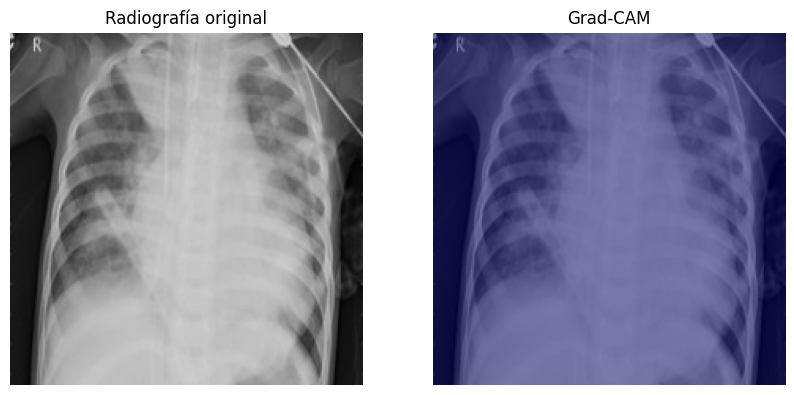

In [15]:
overlay, prob = grad_cam_keras(model, img_rgb, last_conv)
print("Probabilidad clase positiva:", prob)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Radiografía original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,2,2); plt.title("Grad-CAM"); plt.imshow(overlay[..., ::-1]); plt.axis("off")  # cv2 usa BGR
plt.show()


In [4]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl (332.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
